In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

In [ ]:
def load_results(run_dir):
    path = Path(run_dir)
    with open(path, "rb") as fp:
        return pickle.load(fp)


def extract_basin_df(results, basin_id, freq="1D"):
    xr_ds = results[basin_id][freq]["xr"]
    obs = xr_ds["streamflow_obs"].values
    sim = xr_ds["streamflow_sim"].values

    if obs.ndim > 1:
        obs = obs.reshape(obs.shape[0], -1)[:, -1]
    if sim.ndim > 1:
        sim = sim.reshape(sim.shape[0], -1)[:, -1]

    for coord_name in ["date", "time", "datetime"]:
        if coord_name in xr_ds.coords:
            dates = xr_ds[coord_name].values
            break
    else:
        dates = xr_ds[list(xr_ds.coords)[0]].values

    dates = dates.flatten()
    n = min(len(dates), len(obs), len(sim))
    dates, obs, sim = dates[:n], obs[:n], sim[:n]
    mask = ~np.isnan(obs) & ~np.isnan(sim)

    return pd.DataFrame(
        {"obs": obs[mask], "sim": sim[mask]},
        index=pd.to_datetime(dates[mask])
    )

In [ ]:
BASINS = ["oueme_do","oueme_za", "oueme_bo"]

BASIN_LABELS = {
    "oueme_do": "Dome",
    "oueme_za": "Ahlan",
    "oueme_bo": "Bonou",
}

BASIN_AREAS_KM2 = {
    "oueme_do":  8134.443,
    "oueme_za": 38496.43,
    "oueme_bo": 48152.69,
}

def convert_m3s(df, basin_id):
    if basin_id in BASIN_AREAS_KM2:
        factor = BASIN_AREAS_KM2[basin_id] / 86.4
        return df * factor
    return df

res_local = load_results("Results/LSTM_L/runs/test/test_results.p")
res_50    = load_results("Results/LSTM_50C/runs/LSTM-50CL-ft_2603_161250/test/test_results.p")
res_100   = load_results("Results/LSTM_100C/runs/LSTM-100CL-ft_3103_070552/test/test_results.p")
res_150   = load_results("Results/LSTM_150C/runs/LSTM-150CL-ft_0104_123158/test/test_results.p")

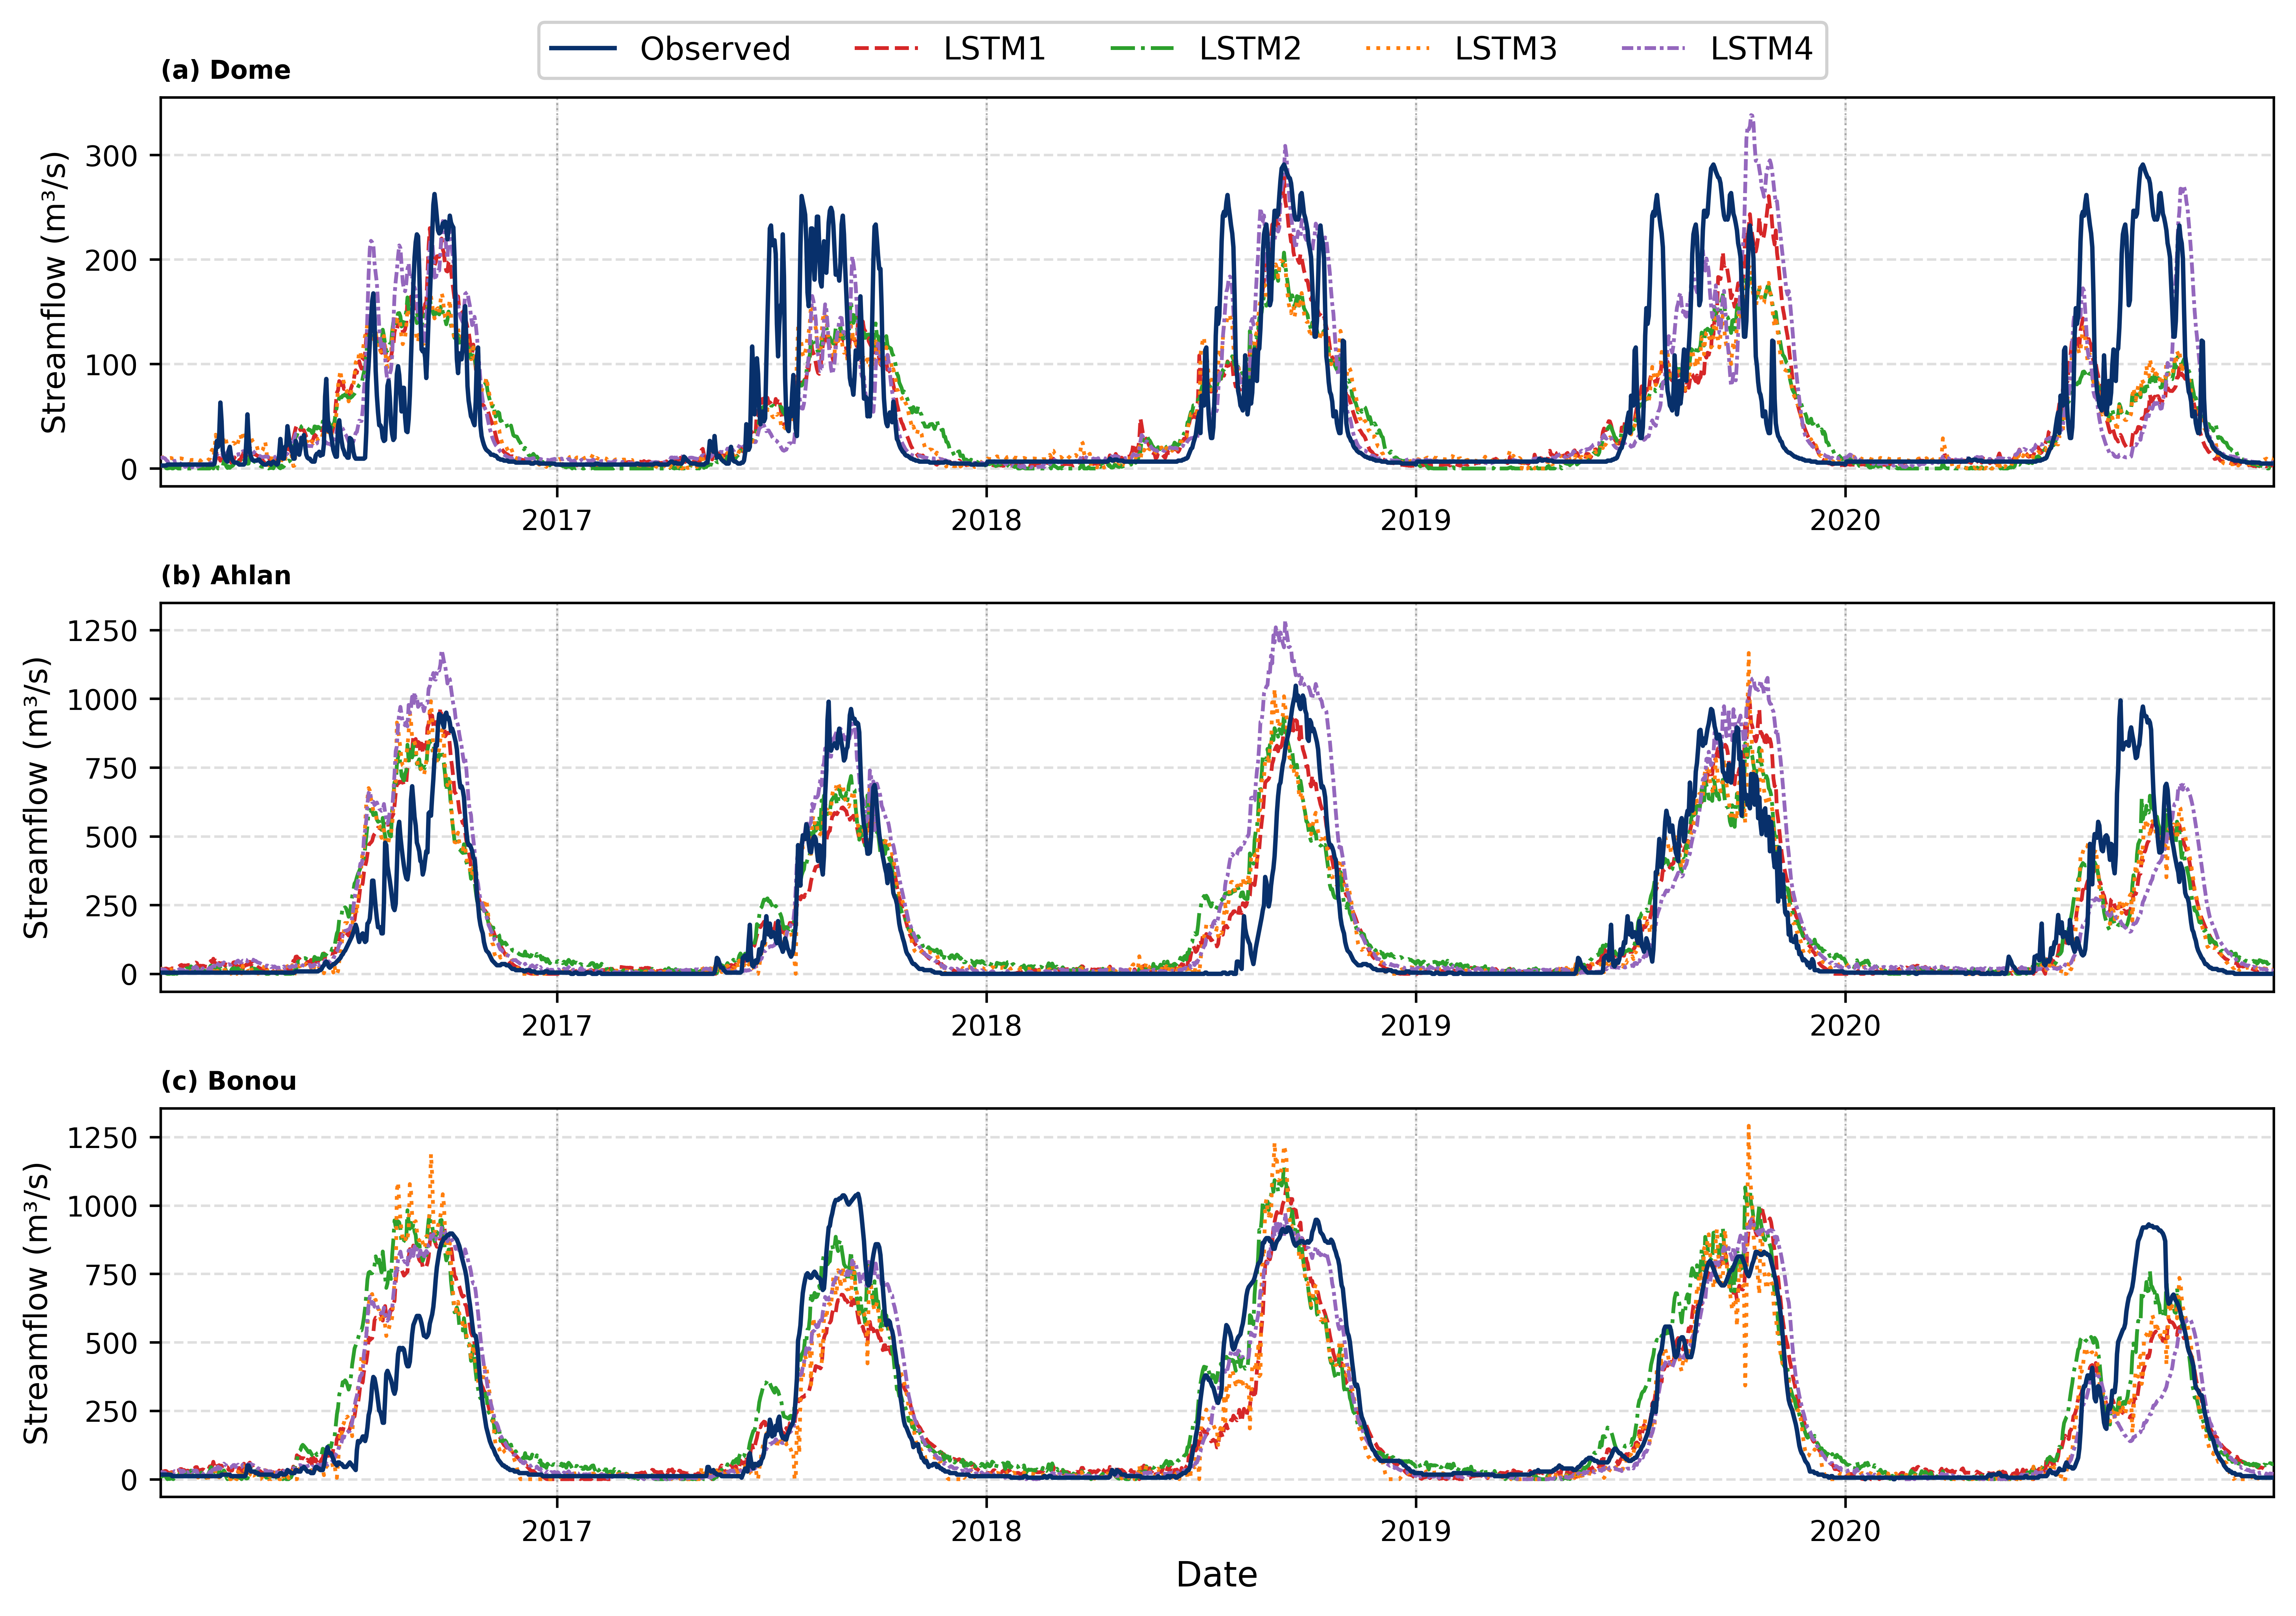

In [ ]:
PLOT_PROPS2 = {
    "obs":     {"color": "#08306b", "lw": 1.4, "ls": "-",            "label": "Observed"},
    "sim_50":  {"color": "#d62728", "lw": 1.2, "ls": "--",           "label": "LSTM1"},
    "sim_100": {"color": "#2ca02c", "lw": 1.2, "ls": "-.",           "label": "LSTM2"},
    "sim_150": {"color": "#ff7f0e", "lw": 1.2, "ls": ":",            "label": "LSTM3"},
    "local":   {"color": "#9467bd", "lw": 1.2, "ls": (0,(3,1,1,1)), "label": "LSTM4"},
}

fig2, axes2 = plt.subplots(
    3, 1, figsize=(12, 8),
    gridspec_kw={"hspace": 0.30},
    dpi = 600
)

for idx, (ax, basin) in enumerate(zip(axes2, BASINS)):

    df_l   = convert_m3s(extract_basin_df(res_local, basin), basin)
    df_50  = convert_m3s(extract_basin_df(res_50,    basin), basin)
    df_100 = convert_m3s(extract_basin_df(res_100,   basin), basin)
    df_150 = convert_m3s(extract_basin_df(res_150,   basin), basin)

    df = (
        df_50[["obs"]]
        .join(df_50 [["sim"]].rename(columns={"sim": "sim_50"}),  how="inner")
        .join(df_100[["sim"]].rename(columns={"sim": "sim_100"}), how="inner")
        .join(df_150[["sim"]].rename(columns={"sim": "sim_150"}), how="inner")
        .join(df_l  [["sim"]].rename(columns={"sim": "local"}),   how="inner")
    )

    df = df.clip(lower=0)
    for col in ["obs", "sim_50", "sim_100", "sim_150", "local"]:
        props = PLOT_PROPS2[col]
        ax.plot(
            df.index, df[col],
            color=props["color"], lw=props["lw"],
            ls=props["ls"],       label=props["label"],
            zorder=5 if col == "obs" else 3,
        )

    letter = chr(ord("a") + idx)
    label  = BASIN_LABELS.get(basin, basin)
    ax.set_title(f"({letter}) {label}", fontsize=8, fontweight="bold", loc="left")

    unit = "m³/s" if basin in BASIN_AREAS_KM2 else "mm/day"
    ax.set_ylabel(f"Streamflow ({unit})", fontsize=10)

    if len(df):
        ax.set_xlim(df.index[0], df.index[-1])

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(True, ls="--", alpha=0.4)

    for year in df.index.year.unique():
        ax.axvline(pd.Timestamp(f"{year}-01-01"), color="gray", lw=0.6, ls=":", alpha=0.6)

axes2[-1].set_xlabel("Date", fontsize=11)
handles2, leg_labels2 = axes2[0].get_legend_handles_labels()
fig2.legend(
    handles2, leg_labels2,
    loc="upper center", ncol=5,
    fontsize=10, bbox_to_anchor=(0.5, 0.93),
    framealpha=0.9, frameon=True,
)
plt.show()